# PERGUNTA 2

# Trabalho remoto compensa?

Importando as Blibliotecas **pandas, numpy e matplotlib.pylot**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Criando **FUNÇÃO** para carregar um arquivo **csv**

In [2]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

Puxando a **FUNÇÃO** através da **VARIÁVEL**, e retornando o **BANCO DE DADOS**

In [3]:
df = carregar_banco_csv(
    r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\4 - TECNICAS DE PROGRAMAÇÃO I (PY) - DE 12-05-2026 A 26-05-2026\PROJETO\salario_ciencia_dados.csv"
)
df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salario_moeda_corrente,moeda_corrente,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


# Cargos totalmente remotos pagam mais, menos ou igual aos presenciais?

Comandos para Retornar a **Média Salarial Geral** e **Média em cada Cargo em suas Modalidades**

In [6]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por tipo de trabalho
salario_por_modalidade = (df.groupby(["cargo","modalidade"])["salario_usd"].mean().unstack().round(2))
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(salario_por_modalidade)


Média salarial geral de todos os funcionários: U$ 145560.56

modalidade                                   Hybrid    On-site     Remote
cargo                                                                    
AI Architect                                    NaN  242108.33  216984.00
AI Developer                              120650.67  154296.00  131653.33
AI Engineer                                21593.00  176015.57  135286.83
AI Product Manager                        120000.00        NaN        NaN
AI Programmer                                   NaN   56735.67   78029.00
AI Research Engineer                            NaN   81206.00   59050.50
AI Scientist                               87386.25  165489.50  100117.58
AWS Data Architect                              NaN        NaN  258000.00
Analytics Engineer                        130000.00  153860.46  159180.20
Analytics Engineering Manager             399880.00        NaN        NaN
Applied Data Scientist                     44643.00

Comandos para Retornar somente **Cargos que possuem somente a Modalidade Remoto** e 
                               **Cargos que possuem somente a Modalidade Presencial**

In [7]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por tipo de modalidade
salario_por_modalidade = (df.groupby(["cargo", "modalidade"])["salario_usd"].mean().unstack().round(2))
# Média salarial por tipo de trabalho (presencial, híbrido, remoto)
salario_por_modalidade = (df.groupby(["cargo", "modalidade"])["salario_usd"].mean().unstack().round(2))
# Filtrar apenas cargos que possuem dados SOMENTE na coluna Remote
cargos_somente_remotos = salario_por_modalidade[salario_por_modalidade.drop(columns=["Remote"], errors="ignore").isna().all(axis=1)]
# Filtrar apenas cargos que possuem empregados SOMENTE na modalidade On-site
cargos_somente_onsite = salario_por_modalidade[salario_por_modalidade.drop(columns=["On-site"], errors="ignore").isna().all(axis=1)]
# Média salarial empregos que só possuem modalidade Presencial
media_remoto = cargos_somente_remotos.mean().round(2)
# Média salarial empregos que só possuem modalidade Presencial
media_presencial = cargos_somente_onsite.mean().round(2)
print(f"Média salarial somente Presencial: U$ {media_presencial["On-site"]}\n Média salarial somente Remoto: U$ {media_remoto["Remote"]}\n")
print(f"Cargos que só possuem empregados na modalidade Remote:\n  {cargos_somente_remotos.reset_index().to_string(index=False)}")
print(f"\nCargos que só possuem empregados na modalidade On-site:\n {cargos_somente_onsite.reset_index().to_string(index=False)}")

Média salarial geral de todos os funcionários: U$ 145560.56

Média salarial somente Presencial: U$ 119626.31
 Média salarial somente Remoto: U$ 105397.73

Cargos que só possuem empregados na modalidade Remote:
                        cargo  Hybrid  On-site    Remote
         AWS Data Architect     NaN      NaN 258000.00
           BI Data Engineer     NaN      NaN  60000.00
    Cloud Database Engineer     NaN      NaN 155000.00
    Compliance Data Analyst     NaN      NaN  45000.00
   Consultant Data Engineer     NaN      NaN 118539.00
          Data Analyst Lead     NaN      NaN  18000.00
  Data Analytics Consultant     NaN      NaN  81500.00
    Data Operations Manager     NaN      NaN 136000.00
      Data Strategy Manager     NaN      NaN 138750.00
               ETL Engineer     NaN      NaN  72286.00
Machine Learning Specialist     NaN      NaN  55000.00
    Manager Data Management     NaN      NaN 125000.00
     Marketing Data Analyst     NaN      NaN 144327.00
         Power BI 

# A resposta muda se compararmos por nível de experiência?

Comandos para comparação **EXPERIÊNCIA x MODALIDADE.**

In [8]:
# Comparação por nível de experiência e modalidade
salario_experiencia_modalidade = (df.groupby(["nivel_experiencia", "modalidade"])["salario_usd"].mean().unstack().round(2))
print("\nMédia salarial por nível de experiência e modalidade de trabalho:\n")
print(salario_experiencia_modalidade.to_string())


Média salarial por nível de experiência e modalidade de trabalho:

modalidade            Hybrid    On-site     Remote
nivel_experiencia                                 
Entry-level         63998.44   96933.89   75154.08
Executive-level    147368.67  185061.71  198580.90
Mid-level           76990.86  129770.81  107083.53
Senior-level       106145.92  166657.46  157343.06


Comando para Visualização em **GRÁFICO** com o resultado das variáveis calculadas

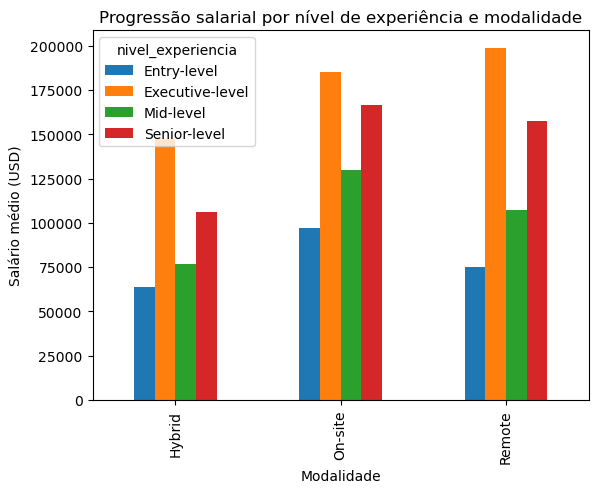

In [10]:
salario_experiencia_modalidade.T.plot(kind="bar")
plt.title("Progressão salarial por nível de experiência e modalidade")
plt.ylabel("Salário médio (USD)")
plt.xlabel("Modalidade")
plt.show()